In [6]:
import sys
import polars as pl
import numpy as np
import seaborn as sns
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, precision_recall_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from pathlib import Path

processed_dir = Path("../data/processed")

parquet_path = processed_dir / "cicids2017_full.parquet"

print(f"Loading dataset from: {parquet_path.name}")
df = pl.read_parquet(parquet_path)
print(f"Dataset loaded: {df.height:,} rows, {df.width} columns.")

cols = df.columns
print("\nAvaible columns for the correlation:")
for col_name in ["Timestamp", "Source IP", "Destination IP", "Source Port", "Destination Port", "Flow Duration"]:
    print(f"\t- {col_name}: {'PRESENT' if col_name in cols else 'NOT FOUND'}")

Loading dataset from: cicids2017_full.parquet
Dataset loaded: 1,993,962 rows, 79 columns.

Avaible columns for the correlation:
	- Timestamp: NOT FOUND
	- Source IP: NOT FOUND
	- Destination IP: NOT FOUND
	- Source Port: NOT FOUND
	- Destination Port: PRESENT
	- Flow Duration: PRESENT


In [7]:
def extract_sequential_correlation_features(df_input: pl.DataFrame, window_size: int = 50) -> pl.DataFrame:
    print(f"Squential correlation calculation on dynamic temporal window of {window_size} flows")

    df_work = df_input.with_columns(
        (pl.int_range(0, pl.len()) // window_size).alias("window_id")
        )

    df_work = df_work.with_columns([
        pl.col("Destination Port")
        .n_unique()
        .over("window_id")
        .alias(f"corr_unique_dst_port_w{window_size}"),

        pl.col("Flow Duration")
        .mean()
        .over("window_id")
        .alias(f"corr_avg_duration_w{window_size}"),

        pl.col("Fwd Packet Length Std")
        .mean()
        .over("window_id")
        .alias(f"corr_avg_fwd_pkt_std_w{window_size}"),

        pl.col("Flow Packets/s")
        .max()
        .over("window_id")
        .alias(f"corr_max_pkt_rate_w{window_size}")
    ]).drop("window_id")

    return df_work


df_correlated = extract_sequential_correlation_features(df, window_size=50)
print("Sequential features computed successfully!")

Squential correlation calculation on dynamic temporal window of 50 flows
Sequential features computed successfully!


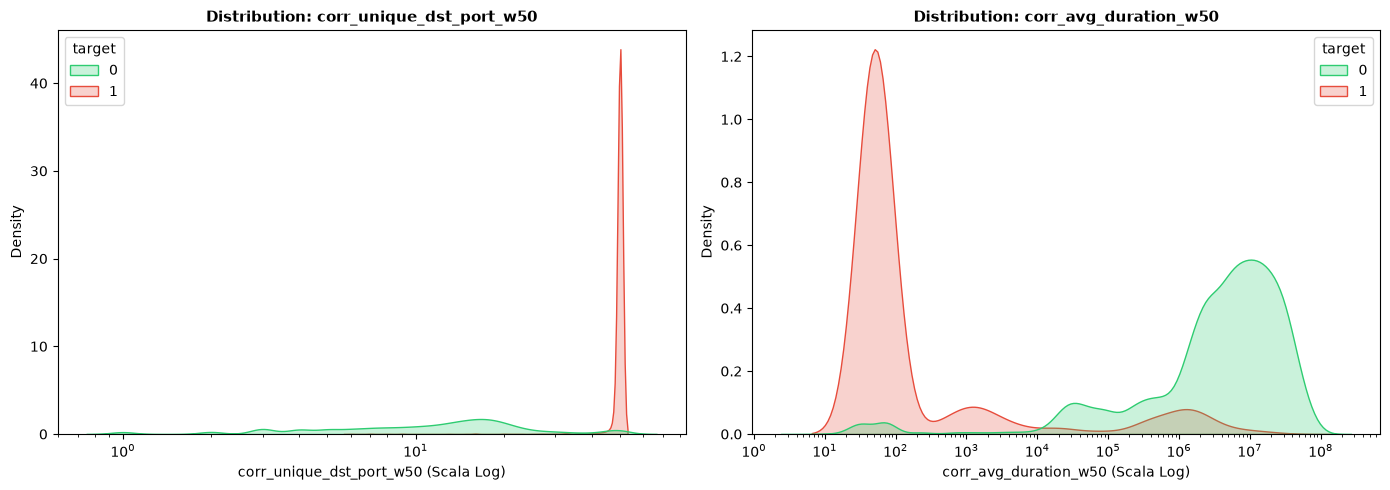

In [8]:
df_correlated = df_correlated.with_columns(
    pl.when(pl.col("Label").str.to_lowercase().str.contains("portscan|recon"))
    .then(1)
    .otherwise(0)
    .alias("target")
)

corr_cols = [c for c in df_correlated.columns if c.startswith("corr_")]
sample_df = df_correlated.select(corr_cols + ["target"]).sample(n=50000, seed=42).to_pandas()

plt.figure(figsize=(14, 5))

for i, col in enumerate(corr_cols[:2], 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(
        data=sample_df,
        x=col,
        hue="target",
        common_norm=False,
        palette={0: "#2ecc71", 1: "#e74c3c"},
        fill=True,
        log_scale=True
    )
    plt.title(f"Distribution: {col}", fontsize=11, fontweight="bold")
    plt.xlabel(f"{col} (Scala Log)")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()